In [19]:
!pip install scipy

   ---------------------------------------- 0.0/38.7 MB ? eta -:--:--
   ------------- -------------------------- 13.4/38.7 MB 84.0 MB/s eta 0:00:01
   -------------------------- ------------- 25.7/38.7 MB 70.6 MB/s eta 0:00:01
   ---------------------------------------  38.5/38.7 MB 68.0 MB/s eta 0:00:01
   ---------------------------------------- 38.7/38.7 MB 63.0 MB/s  0:00:00


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import seaborn as sns

In [21]:
#charger un csv
df = pd.read_csv('./table.csv')
df.head()

,Attempter,Time,Mental demand,Physical demand,Temporal demand,Performance,Effort,Frustration,Type,Rank
0,1,0:03:10,6,1,5,2,1,3,ray,2
1,1,0:02:10,1,1,2,7,2,1,direct,1
2,2,0:01:30,2,1,1,7,1,4,ray,1
3,2,0:01:30,2,4,2,7,3,5,direct,2
4,3,0:03:40,2,2,4,5,4,6,direct,2


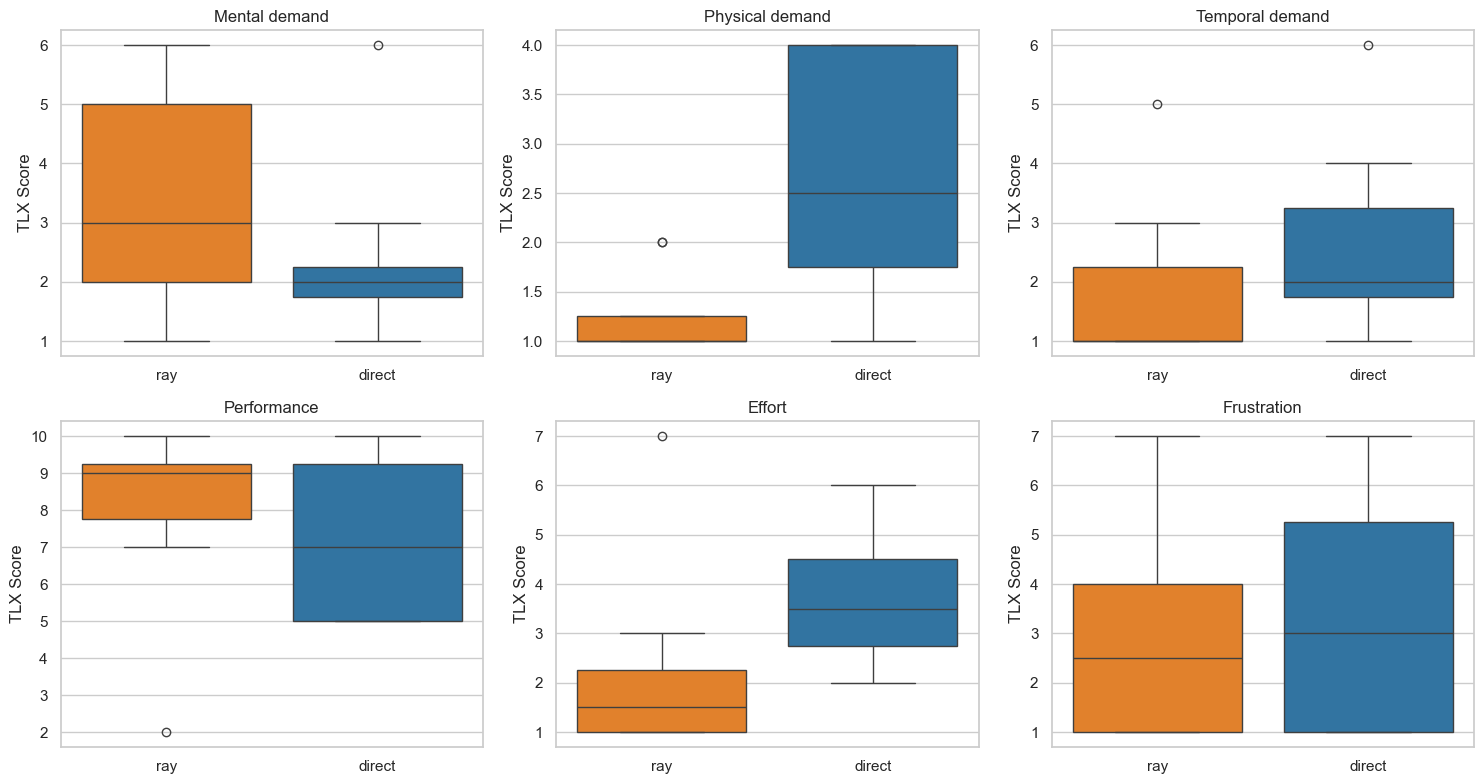

<Figure size 640x480 with 0 Axes>

In [22]:
sns.set(style="whitegrid")

tlx_cols = ["Mental demand", "Physical demand", "Temporal demand", 
            "Performance", "Effort", "Frustration"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), tlx_cols):
    sns.boxplot(data=df, x="Type", y=col, ax=ax,
                palette={"direct": "#1f77b4", "ray": "#ff7f0e"}, hue="Type", dodge=False)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("TLX Score")

plt.tight_layout()
plt.show()
plt.savefig("tlx_boxplots.png")



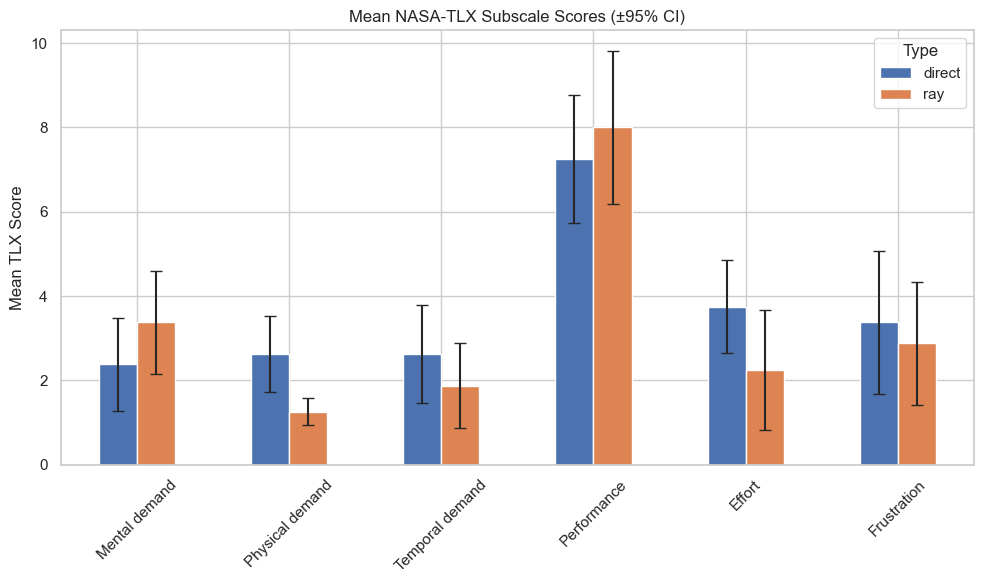

In [23]:
means = df.groupby("Type")[tlx_cols].mean().T
errors = df.groupby("Type")[tlx_cols].sem().T  # Standard error

fig, ax = plt.subplots(figsize=(10, 6))

means.plot(kind="bar", yerr=errors*1.96, ax=ax, capsize=4)
ax.set_ylabel("Mean TLX Score")
ax.set_title("Mean NASA-TLX Subscale Scores (±95% CI)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [24]:
print("Wilcoxon Signed-Rank Test Results:\n")

df_pivot = df.pivot(index="Attempter", columns="Type", values=col)

for col in tlx_cols:
    direct_vals = df[df["Type"]=="direct"][col].values
    ray_vals    = df[df["Type"]=="ray"][col].values
    
    stat, p = wilcoxon(direct_vals, ray_vals)
    print(f"{col:15s}  W={stat:.3f}   p={p:.4f}")


Wilcoxon Signed-Rank Test Results:

Mental demand    W=5.500   p=0.3438
Physical demand  W=0.000   p=0.0312
Temporal demand  W=4.000   p=0.3750
Performance      W=7.500   p=0.6562
Effort           W=7.500   p=0.1641
Frustration      W=6.000   p=0.8125


C:\Users\clara\AppData\Local\Temp\ipykernel_21668\2159213653.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rank1_counts.index, y=rank1_counts.values, ax=ax


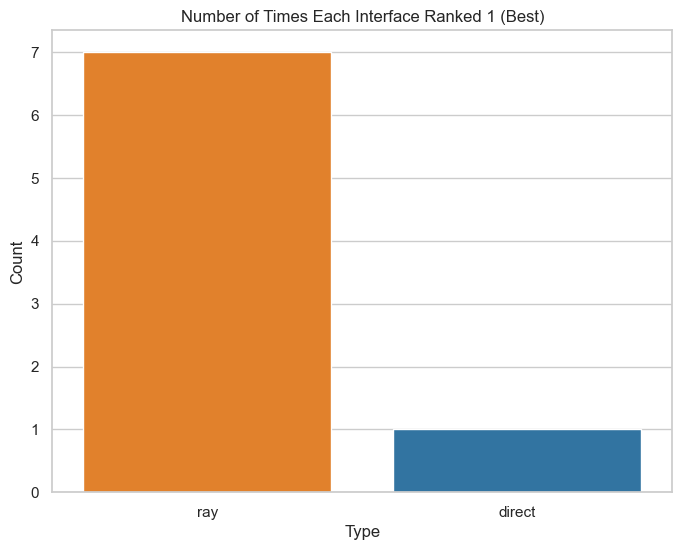

In [25]:
#plot showing number of 'rank' = 1 for each type but not showing 'rank' = 2
rank_counts = df['Rank'].value_counts().sort_index()
rank1_counts = df[df['Rank'] == 1]['Type'].value_counts()
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=rank1_counts.index, y=rank1_counts.values, ax=ax
              , palette={"direct": "#1f77b4", "ray": "#ff7f0e"})
ax.set_title("Number of Times Each Grab was Ranked 1 (Best)")
ax.set_ylabel("Count")
plt.show()

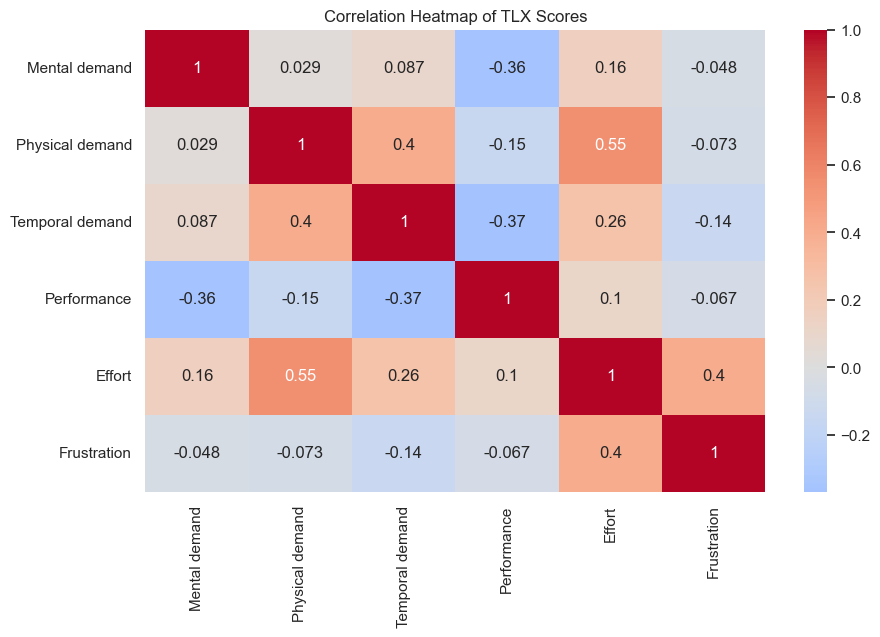

In [28]:
#heatmap to compare each category with the others
corr = df[tlx_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of TLX Scores')
plt.show()